<a href="https://colab.research.google.com/github/TienManh15072007/AI_PROJECT_NHANDIENKHUONMAT/blob/main/AIBUOI6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
from keras.models import Sequential
from keras.layers import Dense, Input
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import Dropout, Flatten
from keras.datasets import mnist
(X_train,y_train),(X_test,y_test)= mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
X_train = X_train.astype("float32")/255
X_test = X_test.astype("float32")/255
X_train = np.expand_dims(X_train,axis=-1)
X_test = np.expand_dims(X_test,axis=-1)
from keras.utils import to_categorical
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [ ]:
model = Sequential()
model.add(Conv2D(32,(3,3),activation = "relu", input_shape=(28,28,1)))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(64,(3,3),activation = "relu"))
model.add(MaxPooling2D(2,2))
model.add(Conv2D(64,(3,3),activation ="relu"))
model.add(Flatten())
model.add(Dense(64,activation = "relu"))
model.add(Dense(10,activation = "softmax"))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer ="rmsprop", loss ="categorical_crossentropy")
history= model.fit(X_train,y_train,epochs=10, validation_data=(X_test,y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 29ms/step - loss: 0.0154 - val_loss: 0.0356
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 80s 28ms/step - loss: 0.0133 - val_loss: 0.0277
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 29ms/step - loss: 0.0104 - val_loss: 0.0495
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - loss: 0.0092 - val_loss: 0.0426
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 30ms/step - loss: 0.0081 - val_loss: 0.0348
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 30ms/step - loss: 0.0065 - val_loss: 0.0538
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 54s 29ms/step - loss: 0.0059 - val_loss: 0.0503
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 58s 31ms/step - loss: 0.0050 - val_loss: 0.0511
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - loss: 0.0044 - val_loss: 0.0553
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - loss: 0.0037 - val_loss: 0.0732


In [ ]:
import matplotlib.pyplot as plt
test_loss, tesst_acc = model.evaluate(X_test,y_test)
print(f"Do chinh xac kiem tra: {test_acc:.4f}")
plt.plot(history.history["accuracy"],label ="Do chinh xac huan luyen")
plt.plot(history.history["val_accuracy"],label="Do chinh xac xac thuc")
plt.xlabel("So lan hoc")
plt.ylabel("Do chinh xac")
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.0732


TypeError: cannot unpack non-iterable float object

In [ ]:
import cv2
img = cv2.imread("/content/22222222222.png")
img_rgb =cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
img_gray = cv2.resize(img_gray,(28,28))
img_inverted= 255 - img_gray
import numpy as np
import matplotlib.pyplot as plt


img_ready=img_inverted.astype('float32')
img_ready=img_ready/256

#DU DOAN
preds= model.predict(img_ready)
digit= np.argmax(preds)

#hien thi
plt.subplot(1,2,1)
plt.imshow(img)
plt.title('so du doan:{}'.format(digit))

plt.subplot(1,2,2)
plt.imshow(img_inverted, cmap='gray')
plt.title(f'so du doan: {digit}')
plt.show()

In [ ]:
from keras.datasets import cifar10
(X_train,y_train),(X_test,y_test) = cifar10.load_data()
X_train = X_train.astype("float32")/255
X_test = X_test.astype("float32")/255
from keras.utils import to_categorical
y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)


In [ ]:
from keras.datasets import cifar10
(x_train,y_train),(x_test,y_test)=cifar10.load_data()
x_train=x_train.astype('float32')/255
x_test=x_test.astype('float32')/255
from keras.utils import to_categorical
y_train=to_categorical(y_train,10)
y_test=to_categorical(y_test,10)
from keras.models import Sequential
from keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout
model = Sequential ()
model.add(Conv2D(32,(3,3), activation='relu', input_shape=(32,32,3),padding = 'same'))
model.add(MaxPooling2D(2,2))
model.add(Conv2D(64,(3,3) ,activation='relu', padding = 'same'))
model.add(MaxPooling2D(2,2))
model.add(Conv2D(128,(3,3) ,activation='relu', padding = 'same'))
model.add(MaxPooling2D(2,2))
model.add(Conv2D( 256,(3,3) ,activation='relu', padding = 'same'))
model.add(MaxPooling2D(2,2))
model.add(Flatten())
model.add(Dense(1000, activation='relu'))
model.add(Dense(10, activation='softmax'))
model.summary()
model.compile(optimizer='rmsprop',loss='categorical_crossentropy',metrics=['accuracy'])
model.fit(x_train,y_train,epochs=5)
model.fit

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1000)           │     1,025,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │        10,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,423,426 (5.43 MB)

 Trainable params: 1,423,426 (5.43 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 211s 134ms/step - accuracy: 0.4502 - loss: 1.5103
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 206s 131ms/step - accuracy: 0.6415 - loss: 1.0107
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 227s 109ms/step - accuracy: 0.7180 - loss: 0.8107
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 200s 108ms/step - accuracy: 0.7603 - loss: 0.6960
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 175s 112ms/step - accuracy: 0.7918 - loss: 0.6105


<bound method TensorFlowTrainer.fit of <Sequential name=sequential_4, built=True>>

In [ ]:
from keras.utils import load_img, img_to_array
img = load_img(/content/frog.jpg,target_size=(32,32))
plt.imshow(img)
img = img_to_array(img)
img = img.reshape(1,32,32,3)
img= img.astype(1,32,32,3)
img = img.astype ("float32")
img = img/255.0
np.argamx(model.prediction(img),axis=-1)


SyntaxError: invalid syntax (400486553.py, line 2)

In [ ]:
import cv2
img = cv2.imread('/content/frog.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
img_gray = cv2.resize(img_gray,(28,28))
img_inverted = 255 - img_gray

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step


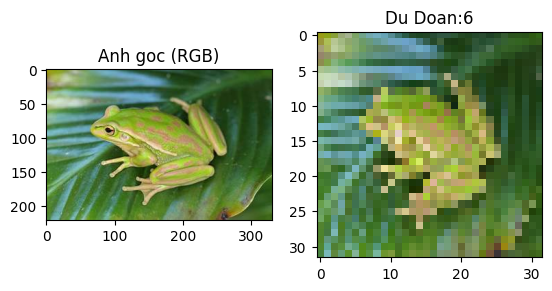

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 # Ensure cv2 is imported for resizing

# The original image loaded by cv2.imread is in img (BGR format)
# The RGB version is in img_rgb (from dRULW7qWKpSh)

# Prepare the image for the CIFAR-10 model
img_for_prediction = cv2.resize(img_rgb, (32, 32)) # Resize to 32x32
img_for_prediction = img_for_prediction.astype('float32') / 255 # Normalize pixel values to 0-1
img_for_prediction = np.expand_dims(img_for_prediction, axis=0) # Add batch dimension (1, 32, 32, 3)

preds = model.predict(img_for_prediction)
digit = np.argmax(preds)

plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title('Anh goc (RGB)')
plt.subplot(1,2,2)
plt.imshow(img_for_prediction[0])
plt.title(f'Du Doan:{digit}')
plt.show()

In [2]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
# 1. TIÊN XỬ LÝ DỮ LIỆU

# Thiết lập đường dẫn dữ liệu
train_dir = "/content/drive/MyDrive/60 tấm selfies - sáng T2"
# Kích thước ảnh và kích thước lô
img_width, img_height = 200, 200
batch_size = 32
# Tăng cường dữ liệu dành cho huấn luyện mô hình
train_datagen = ImageDataGenerator(
    rescale=1.0/255, # Normalize pixel values
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

In [ ]:
import os
print(os.path.exists(train_dir))

True


In [3]:
#Tải dữ liệu huấn luyện
train_generator = train_datagen.flow_from_directory(
  train_dir,
  target_size=(img_width, img_height),
  batch_size=batch_size,
  class_mode="categorical"
)
# XÂY DỰNG MÔ HÌNH CNN
model = Sequential([
  Conv2D(32, (3,3), activation="relu", input_shape=(img_width, img_height, 3)), MaxPooling2D(2,2),
  Conv2D(64, (3,3), activation="relu"),
  MaxPooling2D(2,2),
  Conv2D(128, (3,3), activation="relu"),
  MaxPooling2D(2,2),
  Flatten(),
  Dense(128, activation="relu"),
  Dropout(0.5), # Reduce overfitting
  Dense (22, activation="softmax")
])

Found 1079 images belonging to 22 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

# Tóm tắt cấu hình của mô hình
model.summary()

# HUẤN LUYỆN MÔ HÌNH CNN
epochs = 10
history = model.fit(train_generator, epochs=epochs)

# ĐÁNH GIÁ KẾT QUẢ MÔ HÌNH
plt.plot(history.history['accuracy'], label="Kết quả huấn luyện")
plt.plot(history.history['val_accuracy'], label="Độ chính xác xác thực")
plt.xlabel("Số lần học")
plt.ylabel("Độ chính xác")
plt.legend()
plt.show()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 198, 198, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 97, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 46, 46, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 67712)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     8,667,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 22)             │         2,838 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,763,350 (33.43 MB)

 Trainable params: 8,763,350 (33.43 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
26/34 ━━━━━━━━━━━━━━━━━━━━ 1:50 14s/step - accuracy: 0.0356 - loss: 3.2759

In [1]:
from keras.utils import load_img, img_to_array
import numpy as np
import cv2
import matplotlib.pyplot as plt

# The path '/1 (1).jpg' was previously identified as potentially problematic.
# Please ensure this path points to an actual image file.
# The image will be loaded twice for different processing paths in this cell.

# First loading for Keras utility (commented out the prediction line to avoid NameError earlier)
# Note: This part uses target_size=(32,32) which might not be compatible with the current model.
# If you intend to use this part for prediction, ensure the model's input shape matches (32,32,3)
# or resize img_keras to img_width, img_height (200,200)
img_keras = load_img("/test4.jpg",target_size=(32,32))
plt.imshow(img_keras)
plt.title('Image loaded with Keras utility (32x32)')
plt.show()

img_keras_array = img_to_array(img_keras)
img_keras_array = img_keras_array.reshape(1,32,32,3)
img_keras_array = img_keras_array.astype("float32")
img_keras_array = img_keras_array/255.0
# The following line caused NameError, if you intend to use this for prediction
# ensure the 'model' is defined and uncomment.
# np.argmax(model.predict(img_keras_array),axis=-1)

# Second loading for OpenCV and model prediction
img_cv2 = cv2.imread('/content/test2.jpg')

if img_cv2 is None:
    print(f"Error: Image not found or unable to read at '/1 (1).jpg'. Please check the file path.")
else:
    img_rgb = cv2.cvtColor(img_cv2, cv2.COLOR_BGR2RGB)

    # Removed img_gray and img_inverted as they were not used for the CIFAR-10 model prediction
    # img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    # img_gray = cv2.resize(img_gray,(28,28))
    # img_inverted = 255 - img_gray

    # Prepare the image for the model (input shape 200x200x3)
    # The model expects input shape (200, 200, 3) as defined in cell z1KQGiGAP2pi.
    # Using img_width and img_height from the notebook context (cell QYtzQh5aORJN)
    img_width, img_height = 200, 200 # Re-defining for clarity in this cell
    img_for_prediction = cv2.resize(img_rgb, (img_width, img_height)) # Resize to 200x200
    img_for_prediction = img_for_prediction.astype('float32') / 255 # Normalize pixel values to 0-1
    img_for_prediction = np.expand_dims(img_for_prediction, axis=0) # Add batch dimension (1, 200, 200, 3)

    # Check if 'model' is defined before attempting to predict
    if 'model' in globals():
        preds = model.predict(img_for_prediction)
        digit = np.argmax(preds)

        plt.figure(figsize=(10,5))
        plt.subplot(1,2,1)
        plt.imshow(img_rgb)
        plt.title('Anh goc (RGB)')
        plt.subplot(1,2,2)
        plt.imshow(img_for_prediction[0]) # Display the preprocessed image
        plt.title(f'Du Doan:{digit}')
        plt.show()
    else:
        print("Error: 'model' is not defined. Please run the cell that defines your model (e.g., cell 'z1KQGiGAP2pi') before executing this cell.")

FileNotFoundError: [Errno 2] No such file or directory: '/test4.jpg'

In [ ]:
class_indices = train_generator.class_indices
# Create a reverse mapping from index to class name
idx_to_class = {v: k for k, v in class_indices.items()}

predicted_class_name = idx_to_class.get(digit, 'Unknown Class')

print(f"The predicted digit {digit} corresponds to the class: {predicted_class_name}")
print("Here is the full mapping of class indices to names:")
for idx, class_name in sorted(idx_to_class.items()):
    print(f"  Class {idx}: {class_name}")

The predicted digit 4 corresponds to the class: Ngô Quốc Trung
Here is the full mapping of class indices to names:
  Class 0: HoangKyAnh
  Class 1: Lê Quang Dũng
  Class 2: Lê Tuấn Thành
  Class 3: Lương Ngọc Thuận
  Class 4: Ngô Quốc Trung
  Class 5: Nguyen Ngoc Bao
  Class 6: Nguyễn Hoàng Quế Châu 
  Class 7: Nguyễn Phạm Hoàng An
  Class 8: Nguyễn Thị Khánh Lê
  Class 9: Nguyễn Thị Ngọc Tuyết
  Class 10: Nguyễn Tiến Mạnh
  Class 11: Nguyễn Việt Đức
  Class 12: Nguyễn Đặng Vinh Phúc
  Class 13: Phạm Gia Thành Duy 
  Class 14: Phạm Hứa Nhật Minh 
  Class 15: Phạm Nguyễn Bảo Châu 
  Class 16: Phạm Phú Hoà
  Class 17: Trần Hải Yến
  Class 18: Vũ Quang Thái
  Class 19: Đinh Hữu Khánh Anh
  Class 20: Đoàn Hùng
  Class 21: Đỗ An Phúc
